In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import torch.nn.functional as F
import os
from glob import glob
import rasterio

In [2]:
# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print(torch.cuda.is_available())  # True = CUDA GPU is ready
print(torch.cuda.device_count())  # Number of available GPUs
print(torch.cuda.get_device_name(0))  # Name of first GPU

# Check available CUDA memory
torch.cuda.empty_cache()
free_mem = torch.cuda.mem_get_info()[0] / (1024 ** 3)  # in GB
total_mem = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)  # in GB
print(f"CUDA Free memory: {free_mem:.2f} GB / {total_mem:.2f} GB")

Using device: cuda
True
1
NVIDIA GeForce RTX 3090 Ti
CUDA Free memory: 22.01 GB / 23.99 GB


# ModeL 

In [3]:
class Conv3D_RiverPredictor(nn.Module):
    def __init__(self, in_channels=1, base_filters=32):
        super().__init__()
        
        # Input: [B, 1, 5, 755, 945]
        
        # Encoder with exact downsampling
        self.encoder = nn.Sequential(
            # Layer 1: Keep spatial dims same
            nn.Conv3d(in_channels, base_filters, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(base_filters),
            nn.ReLU(),
            
            # Downsample carefully
            nn.Conv3d(base_filters, base_filters*2, kernel_size=(3, 3, 3), padding=(1, 1, 1), stride=(1, 2, 2)),
            nn.BatchNorm3d(base_filters*2),
            nn.ReLU(),
            # Now: [B, 64, 5, 378, 473] (755//2=378, 945//2=473)
        )
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv3d(base_filters*2, base_filters*4, kernel_size=(3, 3, 3), padding=(1, 1, 1)),
            nn.BatchNorm3d(base_filters*4),
            nn.ReLU(),
        )
        
        # Decoder with exact upsampling
        self.decoder = nn.Sequential(
            # Upsample back to original
            nn.ConvTranspose3d(base_filters*4, base_filters*2, 
                              kernel_size=(1, 2, 2), stride=(1, 2, 2)),
            nn.BatchNorm3d(base_filters*2),
            nn.ReLU(),
            
            # Final conv to get original size
            nn.Conv3d(base_filters*2, 1, kernel_size=(1, 3, 3), padding=(0, 1, 1)),
            nn.Sigmoid()
        )
        
        # Optional: Center crop to exact size
        self.center_crop = nn.Identity()  # We'll fix this if needed
    
    def forward(self, x):
        # x: [B, 1, 5, 755, 945]
        encoded = self.encoder(x)
        bottleneck = self.bottleneck(encoded)
        decoded = self.decoder(bottleneck)  # [B, 1, 5, H', W']
        
        # Take last predicted frame
        output = decoded[:, :, -1, :, :]  # [B, 1, H', W']
        
        # Center crop to match target size if needed
        if output.shape[-2:] != x.shape[-2:]:
            output = self.center_crop_to_match(output, x.shape[-2:])
        
        return output
    
    def center_crop_to_match(self, tensor, target_shape):
        """Center crop tensor to match target H, W"""
        _, _, H, W = tensor.shape
        target_H, target_W = target_shape
        
        if H == target_H and W == target_W:
            return tensor
        
        # Calculate crop margins
        diff_H = H - target_H
        diff_W = W - target_W
        
        start_H = diff_H // 2
        start_W = diff_W // 2
        end_H = start_H + target_H
        end_W = start_W + target_W
        
        return tensor[:, :, start_H:end_H, start_W:end_W]
        # x: [B, 1, 5, H, W]
        encoded = self.encoder(x)
        bottleneck = self.bottleneck(encoded)
        decoded = self.decoder(bottleneck)  # [B, 1, 5, H, W]
        
        # Take only the last predicted frame
        return decoded[:, :, -1, :, :]  # [B, 1, H, W]
    
model = Conv3D_RiverPredictor()
x = torch.randn(4, 1, 5, 64, 67)  # [B, T, C, H, W]
# out = model(x)
# print("Output shape:", out.shape)  # Expected: [B, hidden_dim, H, W]

# Moodel parameter print
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 311553


In [4]:
# Path to your folder (update this path to match your local system)
folder_path = r"D:\RUbel Ahmmed 0421162025\Data\Harirampur Padma\ALL Water Polygon"
# Get all .tif files in the folder
LS_NIR = sorted(glob(os.path.join(folder_path, '*.tif')))
print(f"Found {len(LS_NIR)} GeoTIFF images.")
# Check the number of bands for each .tif file
for tif in LS_NIR:
    with rasterio.open(tif) as src:
        print(f"{os.path.basename(tif)} - Number of bands: {src.count}")

Found 38 GeoTIFF images.
1988_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
1989_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
1990_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
1991_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
1992_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
1993_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
1994_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
1995_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
1996_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
1997_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
1998_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
1999_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
2000_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
2001_LS5_Padma_Harirampur_WaterPolygon_mask.tif - Number of bands: 1
2002_LS7_

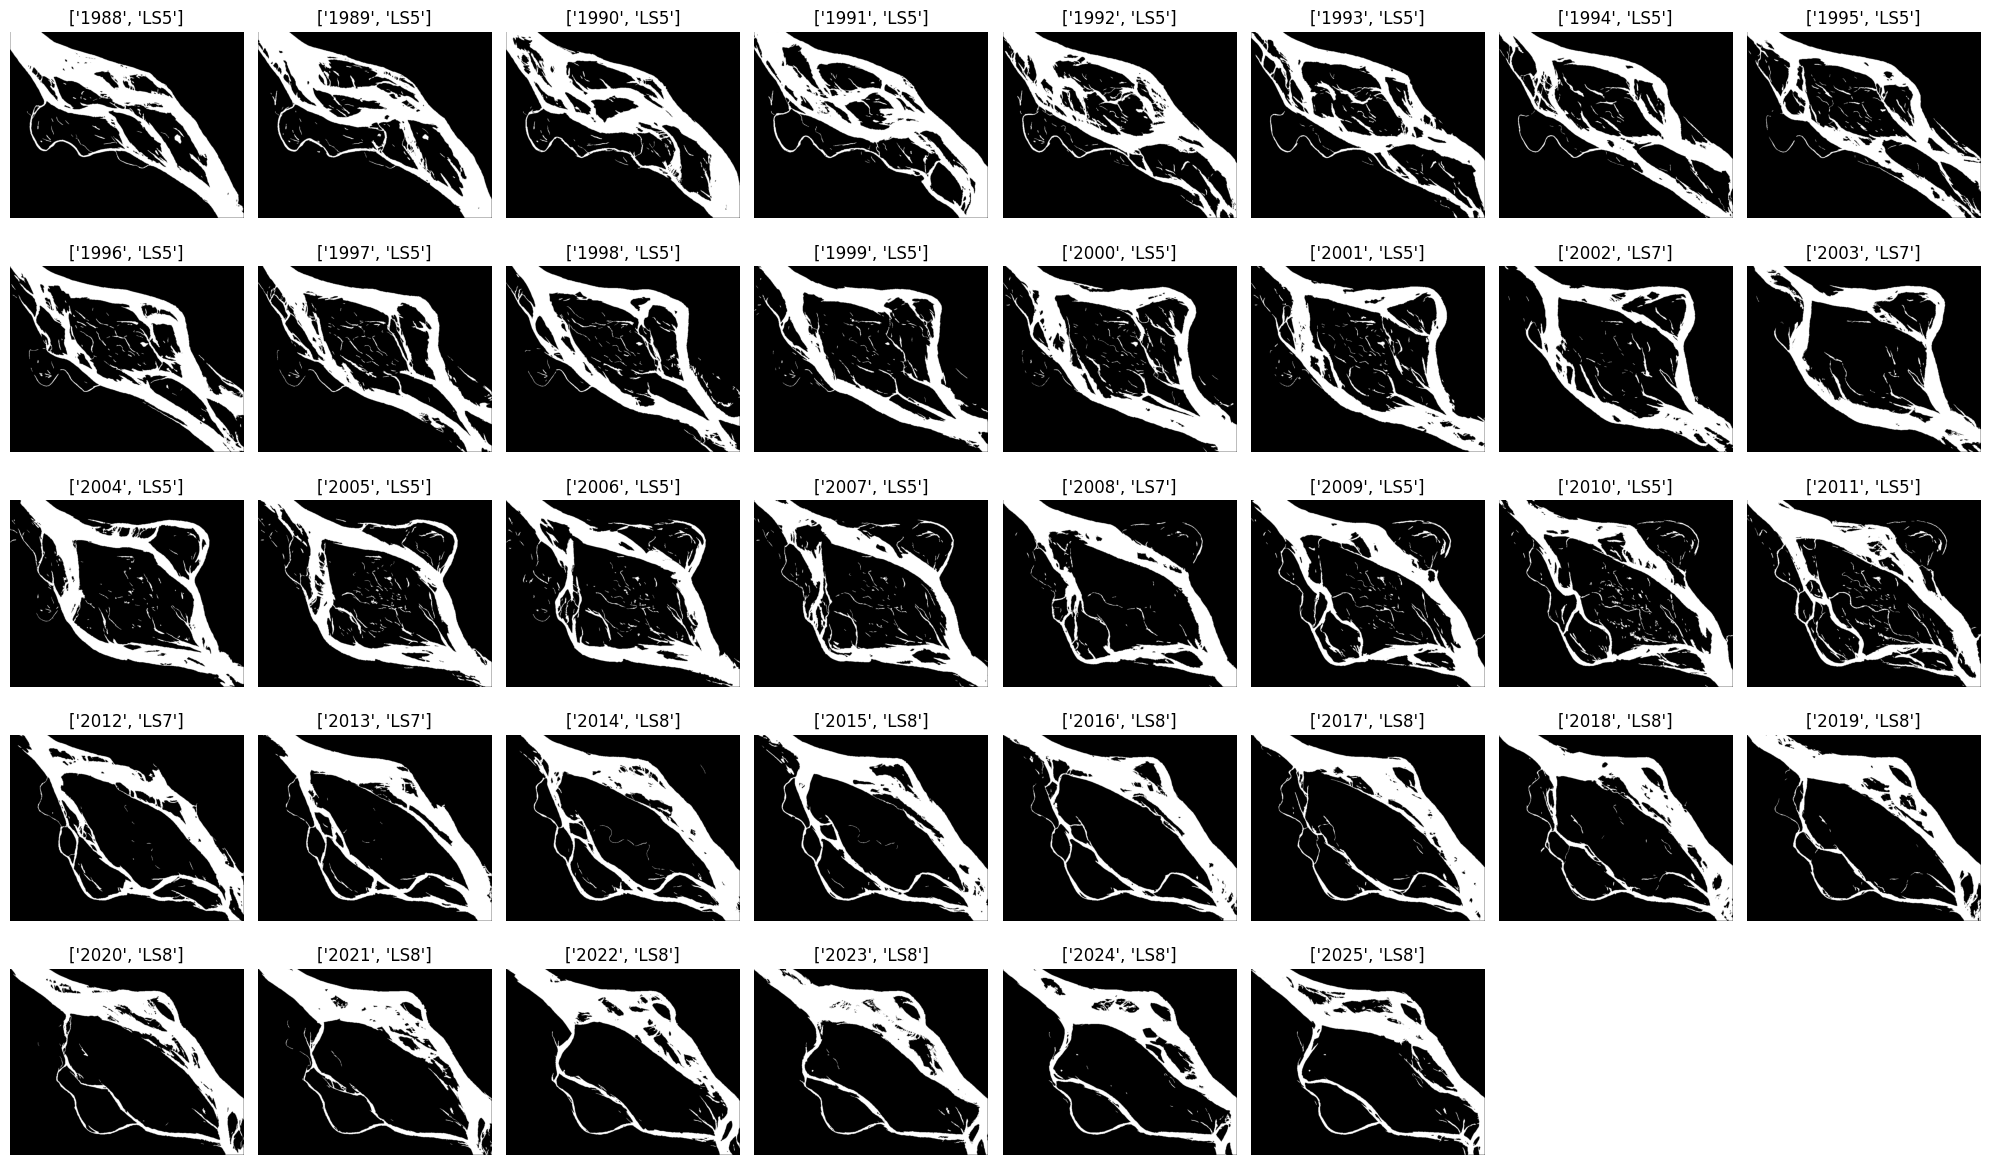

In [6]:
plt.figure(figsize=(20, 12))
for i, tif in enumerate(LS_NIR[:38]):  # Display first 6 images
    with rasterio.open(tif) as src:
        band1 = src.read(1)
    plt.subplot(5, 8, i+1)
    plt.imshow(band1, cmap='gray')
    # Display split upto  2nd _ filename as title
    plt.title(os.path.basename(tif).split('_')[0:2])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
LS_NIR_List = []
crs = None
transform = None
for i, tif in enumerate(LS_NIR):
    with rasterio.open(tif) as src:
        img = src.read(1).astype(np.float32)  # Read all 3 bands
        # img = np.moveaxis(img, 0, -1)  # Reorder the dimensions (from [bands, height, width] to [height, width, bands])
        LS_NIR_List.append(img)
        if i == 0:
            crs = src.crs
            transform = src.transform
# Stack into time-series array: shape [time, height, width, bands]
LS_NIR_Seq = np.stack(LS_NIR_List).astype(np.float32)
print("Image sequence shape:", LS_NIR_Seq.shape)
print("CRS:", crs)
print("Transform:", transform)

data = torch.tensor(LS_NIR_Seq).squeeze(1)  # [time, channels, height, width]
print("Data tensor shape:", data.shape)

Image sequence shape: (38, 755, 945)
CRS: EPSG:32645
Transform: | 30.00, 0.00, 785220.00|
| 0.00,-30.00, 2630850.00|
| 0.00, 0.00, 1.00|
Data tensor shape: torch.Size([38, 755, 945])


In [6]:
def create_dataset(data, input_seq_len, target_seq_len):
    inputs = []
    targets = []
    total_seq_len = input_seq_len + target_seq_len
    for i in range(len(data) - total_seq_len + 1):
        input_seq = data[i:i+input_seq_len]
        target_seq = data[i+input_seq_len:i+total_seq_len]
        inputs.append(input_seq)
        targets.append(target_seq)
    return torch.stack(inputs), torch.stack(targets)

input_seq_len = 5
target_seq_len = 1
inputs, targets = create_dataset(data, input_seq_len, target_seq_len)
inputs = inputs.unsqueeze(2)  # Add channel dimension
print("Inputs shape:", inputs.shape)
print("Targets shape:", targets.shape)

x_train = inputs[:32].permute(0, 2, 1, 3, 4)  # [B, C, T, H, W]
y_train = targets[:32]
x_val = inputs[32:].permute(0, 2, 1, 3, 4)     # [B, C, T, H, W]
y_val = targets[32:]
x_test = inputs[32:].permute(0, 2, 1, 3, 4)    # [B, C, T, H, W]
y_test = targets[32:]
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

Inputs shape: torch.Size([33, 5, 1, 755, 945])
Targets shape: torch.Size([33, 1, 755, 945])
x_train shape: torch.Size([32, 1, 5, 755, 945])
y_train shape: torch.Size([32, 1, 755, 945])
x_val shape: torch.Size([1, 1, 5, 755, 945])
y_val shape: torch.Size([1, 1, 755, 945])
x_test shape: torch.Size([1, 1, 5, 755, 945])
y_test shape: torch.Size([1, 1, 755, 945])


In [7]:
train_dateset = TensorDataset(x_train, y_train)
dataloader = DataLoader(train_dateset, batch_size=4, shuffle=True)
test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True)

for batch_inputs, batch_targets in dataloader:
    print("Batch inputs shape:", batch_inputs.shape)
    print("Batch targets shape:", batch_targets.shape)
    model = Conv3D_RiverPredictor()
    out = model(batch_inputs)
    print("Model output shape:", out.shape)
    break  # Just to check one batch

Batch inputs shape: torch.Size([4, 1, 5, 755, 945])
Batch targets shape: torch.Size([4, 1, 755, 945])
Model output shape: torch.Size([4, 1, 755, 945])


# Training Loop

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

# Ensure output matches target
def ensure_shape_match(output, target):
    """If shapes don't match, center crop output to target size"""
    if output.shape[-2:] != target.shape[-2:]:
        # Calculate center crop
        out_H, out_W = output.shape[-2:]
        tar_H, tar_W = target.shape[-2:]
        
        diff_H = out_H - tar_H
        diff_W = out_W - tar_W
        
        if diff_H % 2 == 0 and diff_W % 2 == 0:
            start_H = diff_H // 2
            start_W = diff_W // 2
            output = output[:, :, start_H:start_H+tar_H, start_W:start_W+tar_W]
        else:
            # If odd difference, pad target instead
            pad_H = (out_H - tar_H) // 2
            pad_W = (out_W - tar_W) // 2
            target = F.pad(target, (pad_W, pad_W, pad_H, pad_H))
    
    return output, target

# Modified training loop
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50
loss_history = []
val_loss_history = []
best_val_loss = float('inf')

# Save directory
save_dir = r"D:\RUbel Ahmmed 0421162025\pytorch_venv\Final Model\Model_03_Conv3d_EncoderDecoder"   # use raw string for Windows paths
# make sure the folder exists
os.makedirs(save_dir, exist_ok=True)


for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    
    for batch_idx, (inputs, targets) in enumerate(dataloader):
        optimizer.zero_grad()
        outputs = model(inputs)
        
        # Fix shape mismatch if any
        if outputs.shape[-2:] != targets.shape[-2:]:
            outputs, targets = ensure_shape_match(outputs, targets)
        
        loss = criterion(outputs, targets)
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        epoch_loss += loss.item() * inputs.size(0)
        
        # # Print batch progress
        # if batch_idx % 1 == 0:
        #     print(f"  Batch {batch_idx}: Loss = {loss.item():.6f}")
    
    epoch_loss /= len(dataloader.dataset)
    loss_history.append(epoch_loss)
    
    # Save model
    model_path = os.path.join(save_dir, f"conv3d_model_epoch_{epoch+1:03d}.pth")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': epoch_loss,
    }, model_path)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(x_val)
        
        # Fix validation shape mismatch
        if val_outputs.shape[-2:] != y_val.shape[-2:]:
            val_outputs, y_val_fixed = ensure_shape_match(val_outputs, y_val)
            val_loss = criterion(val_outputs, y_val_fixed).item()
        else:
            val_loss = criterion(val_outputs, y_val).item()
        
        val_loss_history.append(val_loss)
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_path = os.path.join(save_dir, "conv3d_best_model.pth")
            torch.save(model.state_dict(), best_model_path)
    
    # Print epoch results
    print(f"Epoch [{epoch+1}/{epochs}], "
          f"Train Loss: {epoch_loss:.6f}, "
          f"Val Loss: {val_loss:.6f}, "
          f"Best Val: {best_val_loss:.6f}")
    
    # Learning rate scheduling
    if epoch > 0 and val_loss_history[-1] > val_loss_history[-2]:
        # Reduce LR on plateau
        for param_group in optimizer.param_groups:
            param_group['lr'] *= 0.5
        print(f"  Reduced learning rate to {optimizer.param_groups[0]['lr']}")

Epoch [1/50], Train Loss: 0.353919, Val Loss: 0.434720, Best Val: 0.434720
Epoch [2/50], Train Loss: 0.222784, Val Loss: 0.218291, Best Val: 0.218291
Epoch [3/50], Train Loss: 0.219950, Val Loss: 0.187822, Best Val: 0.187822
Epoch [4/50], Train Loss: 0.216230, Val Loss: 0.178063, Best Val: 0.178063
Epoch [5/50], Train Loss: 0.215402, Val Loss: 0.179213, Best Val: 0.178063
  Reduced learning rate to 0.0005
Epoch [6/50], Train Loss: 0.214856, Val Loss: 0.166014, Best Val: 0.166014
Epoch [7/50], Train Loss: 0.213594, Val Loss: 0.172025, Best Val: 0.166014
  Reduced learning rate to 0.00025
Epoch [8/50], Train Loss: 0.213156, Val Loss: 0.164037, Best Val: 0.164037
Epoch [9/50], Train Loss: 0.212791, Val Loss: 0.166715, Best Val: 0.164037
  Reduced learning rate to 0.000125
Epoch [10/50], Train Loss: 0.211871, Val Loss: 0.165516, Best Val: 0.164037
Epoch [11/50], Train Loss: 0.211724, Val Loss: 0.165247, Best Val: 0.164037
Epoch [12/50], Train Loss: 0.211552, Val Loss: 0.165253, Best Val: 0

# Evaluation and Plot

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import pandas as pd

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def evaluate_model(model, test_loader, device='cpu'):
    """Comprehensive evaluation of river prediction model"""
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            preds = (outputs > 0.5).float()
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
    
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    
    return all_preds, all_targets

def calculate_river_metrics(y_true, y_pred):
    """Calculate river-specific metrics"""
    y_true_np = y_true.cpu().numpy().flatten()
    y_pred_np = y_pred.cpu().numpy().flatten()
    
    # Basic classification metrics
    cm = confusion_matrix(y_true_np, y_pred_np)
    tn, fp, fn, tp = cm.ravel()
    
    # River-specific metrics
    total_pixels = y_true_np.size
    water_pixels_true = np.sum(y_true_np == 1)
    water_pixels_pred = np.sum(y_pred_np == 1)
    
    # Hydrological metrics
    iou_water = tp / (tp + fp + fn + 1e-10)
    iou_land = tn / (tn + fp + fn + 1e-10)
    
    # Connectivity metrics (approximate)
    from scipy import ndimage
    pred_water = y_pred[0, 0].cpu().numpy() if y_pred.dim() > 2 else y_pred.cpu().numpy()
    true_water = y_true[0, 0].cpu().numpy() if y_true.dim() > 2 else y_true.cpu().numpy()
    
    # Number of connected water bodies
    labeled_pred, num_features_pred = ndimage.label(pred_water > 0.5)
    labeled_true, num_features_true = ndimage.label(true_water > 0.5)
    
    metrics = {
        'accuracy': (tp + tn) / (tp + tn + fp + fn),
        'precision_water': tp / (tp + fp + 1e-10),
        'recall_water': tp / (tp + fn + 1e-10),
        'f1_water': 2 * tp / (2 * tp + fp + fn + 1e-10),
        'iou_water': iou_water,
        'iou_land': iou_land,
        'water_pixels_true': water_pixels_true,
        'water_pixels_pred': water_pixels_pred,
        'water_area_ratio_true': water_pixels_true / total_pixels,
        'water_area_ratio_pred': water_pixels_pred / total_pixels,
        'num_water_bodies_true': num_features_true,
        'num_water_bodies_pred': num_features_pred,
        'false_positive_rate': fp / (fp + tn + 1e-10),
        'false_negative_rate': fn / (fn + tp + 1e-10),
    }
    
    return metrics, cm

def generate_detailed_report(metrics, model_name="Conv3D River Predictor"):
    """Generate detailed evaluation report"""
    report = f"""
    {'='*60}
    RIVER PLANFORM PREDICTION EVALUATION REPORT
    {'='*60}
    Model: {model_name}
    Timestamp: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
    
    {'-'*60}
    CLASSIFICATION METRICS:
    {'-'*60}
    Accuracy:           {metrics['accuracy']:.4f}
    Precision (Water):  {metrics['precision_water']:.4f}
    Recall (Water):     {metrics['recall_water']:.4f}
    F1-Score (Water):   {metrics['f1_water']:.4f}
    
    {'-'*60}
    SEGMENTATION METRICS:
    {'-'*60}
    IoU (Water):        {metrics['iou_water']:.4f}
    IoU (Land):         {metrics['iou_land']:.4f}
    False Positive Rate: {metrics['false_positive_rate']:.4f}
    False Negative Rate: {metrics['false_negative_rate']:.4f}
    
    {'-'*60}
    RIVER MORPHOLOGY:
    {'-'*60}
    Water Pixels (True):  {metrics['water_pixels_true']:,}
    Water Pixels (Pred):  {metrics['water_pixels_pred']:,}
    Water Area Ratio:     {metrics['water_area_ratio_true']:.4f}
    Water Bodies (True):  {metrics['num_water_bodies_true']}
    Water Bodies (Pred):  {metrics['num_water_bodies_pred']}
    
    {'='*60}
    """
    print(report)
    
    # Return as dictionary for further analysis
    return metrics

# ====== MAIN EVALUATION PIPELINE ======
if __name__ == "__main__":
    # Load your trained model
    model = Conv3D_RiverPredictor()  # Your model class
    model.load_state_dict(torch.load(r'D:\RUbel Ahmmed 0421162025\pytorch_venv\Final Model\Model_03_Conv3d_EncoderDecoder Padma dpsk\conv3d_best_model.pth'))
    model.eval()
    
    # Move to device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    # 1. Evaluate on test data
    print("Evaluating model on test data...")
    y_pred, y_true = evaluate_model(model, test_loader, device)
    
    # 2. Calculate metrics
    metrics, cm = calculate_river_metrics(y_true, y_pred)
    
    # 3. Generate report
    generate_detailed_report(metrics)
    
    

Evaluating model on test data...

    RIVER PLANFORM PREDICTION EVALUATION REPORT
    Model: Conv3D River Predictor
    Timestamp: 2026-01-30 14:39:11

    ------------------------------------------------------------
    CLASSIFICATION METRICS:
    ------------------------------------------------------------
    Accuracy:           0.9361
    Precision (Water):  0.8084
    Recall (Water):     0.8934
    F1-Score (Water):   0.8487

    ------------------------------------------------------------
    SEGMENTATION METRICS:
    ------------------------------------------------------------
    IoU (Water):        0.7372
    IoU (Land):         0.9221
    False Positive Rate: 0.0532
    False Negative Rate: 0.1066

    ------------------------------------------------------------
    RIVER MORPHOLOGY:
    ------------------------------------------------------------
    Water Pixels (True):  143,162
    Water Pixels (Pred):  158,216
    Water Area Ratio:     0.2007
    Water Bodies (True):  125

# Loss histroy plot

In [ ]:
def plot_training_history(loss_history, val_loss_history, save_path=None):
    """Plot training and validation loss history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss curves
    ax1.plot(loss_history, label='Training Loss', linewidth=2, color='blue')
    ax1.plot(val_loss_history, label='Validation Loss', linewidth=2, color='red')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training History', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Log scale for better visualization
    ax2.semilogy(loss_history, label='Training Loss', linewidth=2, color='blue')
    ax2.semilogy(val_loss_history, label='Validation Loss', linewidth=2, color='red')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss (log scale)')
    ax2.set_title('Training History (Log Scale)', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Model Training Progress', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Load the training history
train_history_path = r'D:\RUbel Ahmmed 0421162025\pytorch_venv\Final Model\Model_04_Unet\training_history_simple.npy'
history = np.load(train_history_path, allow_pickle=True).item()
# print("Keys in history:", history.keys())
# Keys in history: dict_keys(['train_losses', 'val_losses', 'best_val_loss', 'num_epochs_trained', 'loss_weights', 'pos_weight'])
train_losses = history['train_losses']
val_losses = history['val_losses']
# Plot training history
plot_training_history(train_losses, val_losses, save_path=None)

# Actual vs Prediction Plot

In [20]:
# x_test shape: torch.Size([1, 1, 5, 755, 945])
# y_test shape: torch.Size([1, 1, 755, 945])#
x_test = x_test.permute(0, 2, 1, 3, 4)  # [B, C, T, H, W] to [B, T, C, H, W] 
print("x_test shape:", x_test.shape)

x_test shape: torch.Size([1, 5, 1, 755, 945])


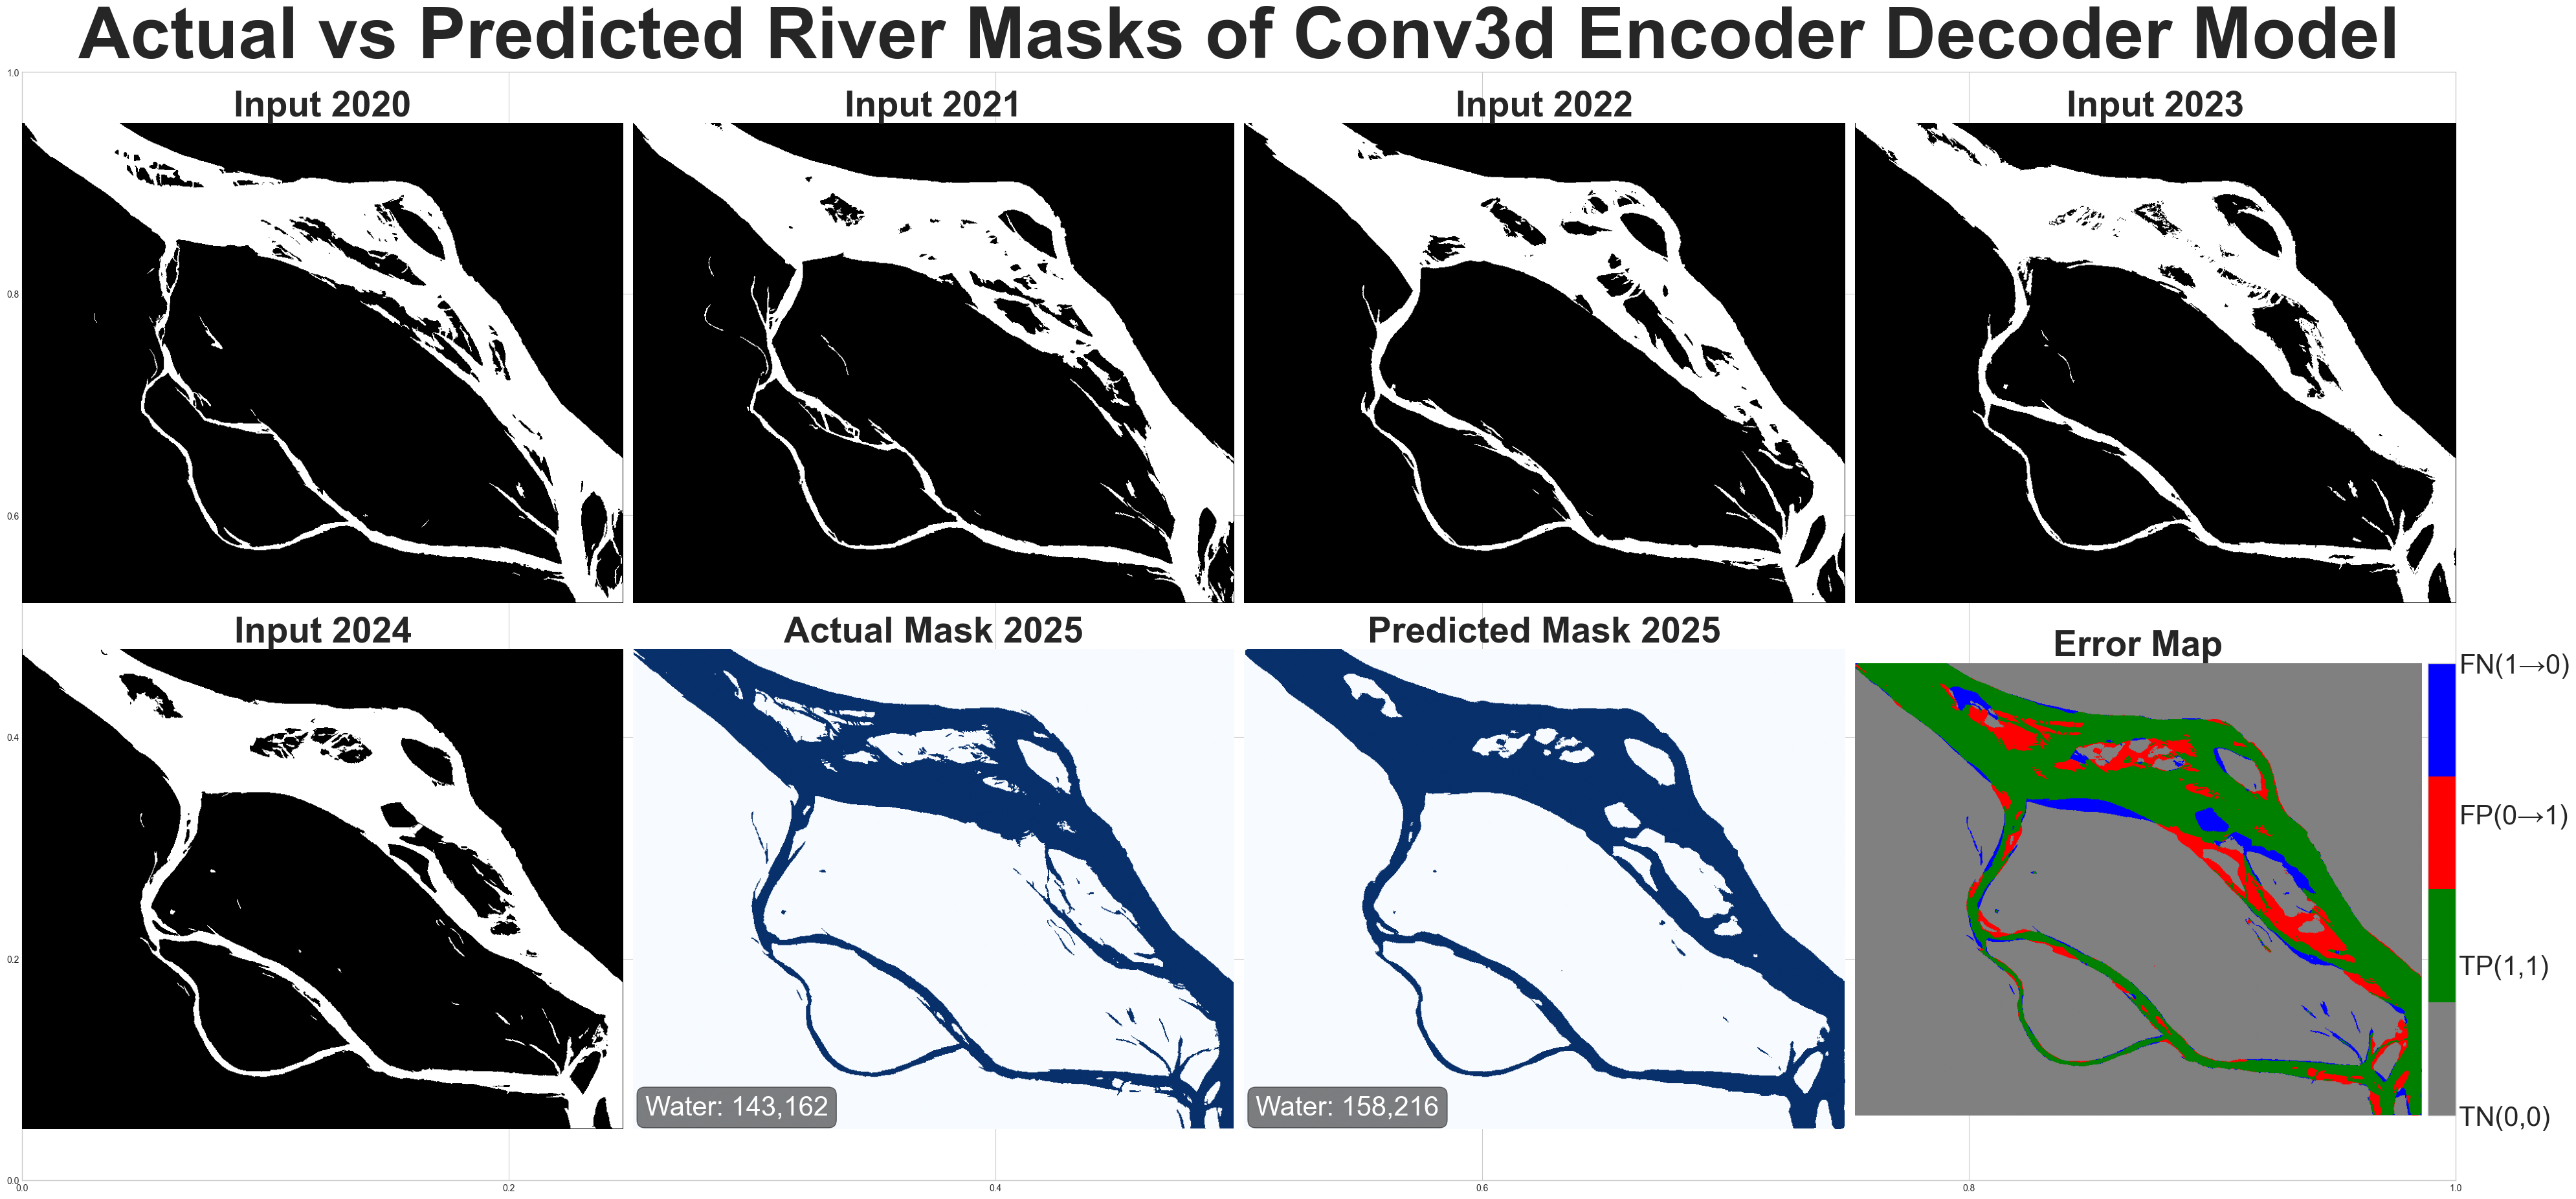

In [21]:
def visualize_evaluation(y_test, y_pred, x_test, sample_idx=0, save_path=None):
    """Enhanced visualization with metrics - assuming x_test has shape [batch, seq_len, 1, H, W]"""
    # Ensure tensors
    if isinstance(y_test, np.ndarray):
        y_test = torch.from_numpy(y_test)
    if isinstance(x_test, np.ndarray):
        y_pred = torch.from_numpy(y_pred)
    
    # Ensure binary
    y_test_bin = y_test.int()
    x_test_bin = x_test.int()
    y_pred_bin = (y_pred > 0.5).int()
    
    # Classification map
    result = torch.zeros_like(y_test_bin, dtype=torch.int8)
    result[(y_test_bin == 1) & (y_pred_bin == 1)] = 1     # True Positive
    result[(y_test_bin == 0) & (y_pred_bin == 1)] = 2     # False Positive
    result[(y_test_bin == 1) & (y_pred_bin == 0)] = 3     # False Negative
    
    # Colors and labels
    cmap = ListedColormap(['gray', 'green', 'red', 'blue'])
    labels = ['TN(0,0)', 'TP(1,1)', 'FP(0→1)', 'FN(1→0)']
    
    # Calculate metrics
    metrics, cm = calculate_river_metrics(y_test_bin, y_pred_bin)
    
    # Create figure with 2×4 grid
    fig = plt.figure(figsize=(40, 20))
    
    # Assuming x_test shape: [batch, sequence_len=5, 1, H, W]
    time_labels = ['2020', '2021', '2022', '2023', '2024']
    plt.title('Actual vs Predicted River Masks of Conv3d Encoder Decoder Model', fontsize=80, fontweight='bold')
    # Plot all 5 input frames (columns 1-5)
    for i in range(5):
        ax = plt.subplot(2, 4, i+1)
        
        # Get the i-th frame in the sequence
        if x_test.dim() == 5:  # [batch, seq_len, channels, H, W]
            img_to_show = x_test[sample_idx, i, 0].cpu().numpy()
        elif x_test.dim() == 4:  # [batch, seq_len*channels, H, W]
            img_to_show = x_test[sample_idx, i].cpu().numpy()
        else:
            img_to_show = x_test[sample_idx].cpu().numpy()
        
        ax.imshow(img_to_show, cmap='gray')
        ax.set_title(f'Input {time_labels[i]}', fontsize=40, fontweight='bold')
        ax.axis('off')
    
    # 6: Actual River Mask (t)
    ax6 = plt.subplot(2, 4, 6)
    actual_mask = y_test[sample_idx, 0].cpu().numpy() if y_test.dim() > 2 else y_test.cpu().numpy()
    ax6.imshow(actual_mask, cmap='Blues', vmin=0, vmax=1)
    ax6.set_title('Actual Mask 2025', fontsize=40, fontweight='bold')
    ax6.axis('off')
    ax6.text(0.02, 0.02, f'Water: {metrics["water_pixels_true"]:,}', 
             transform=ax6.transAxes, color='white', fontsize=30,
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    
    # 7: Predicted River Mask (t)
    ax7 = plt.subplot(2, 4, 7)
    pred_mask = y_pred[sample_idx, 0].cpu().numpy() if y_pred.dim() > 2 else y_pred.cpu().numpy()
    ax7.imshow(pred_mask, cmap='Blues', vmin=0, vmax=1)
    ax7.set_title('Predicted Mask 2025', fontsize=40, fontweight='bold')
    ax7.axis('off')
    ax7.text(0.02, 0.02, f'Water: {metrics["water_pixels_pred"]:,}', 
             transform=ax7.transAxes, color='white', fontsize=30,
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    
    # 8: Error Classification
    ax8 = plt.subplot(2, 4, 8)
    error_map = result[sample_idx, 0].cpu().numpy() if result.dim() > 2 else result.cpu().numpy()
    im = ax8.imshow(error_map, cmap=cmap, vmin=0, vmax=3)
    ax8.set_title('Error Map', fontsize=40, fontweight='bold')
    ax8.axis('off')
    
    # Add colorbar for error map
    divider = make_axes_locatable(ax8)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = plt.colorbar(im, cax=cax, ticks=[0, 1, 2, 3])
    cbar.ax.set_yticklabels(labels, fontsize=30)
   
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()

visualize_evaluation(y_test, y_pred, x_test, sample_idx=0, save_path=None)

# Evaluation Matrix plot

In [23]:
# x_test shape: torch.Size([1, 1, 5, 755, 945])
# y_test shape: torch.Size([1, 1, 755, 945])#
x_test = x_test.permute(0, 2, 1, 3, 4)  # [B, C, T, H, W] to [B, T, C, H, W] 
print("x_test shape:", x_test.shape)

x_test shape: torch.Size([1, 1, 5, 755, 945])


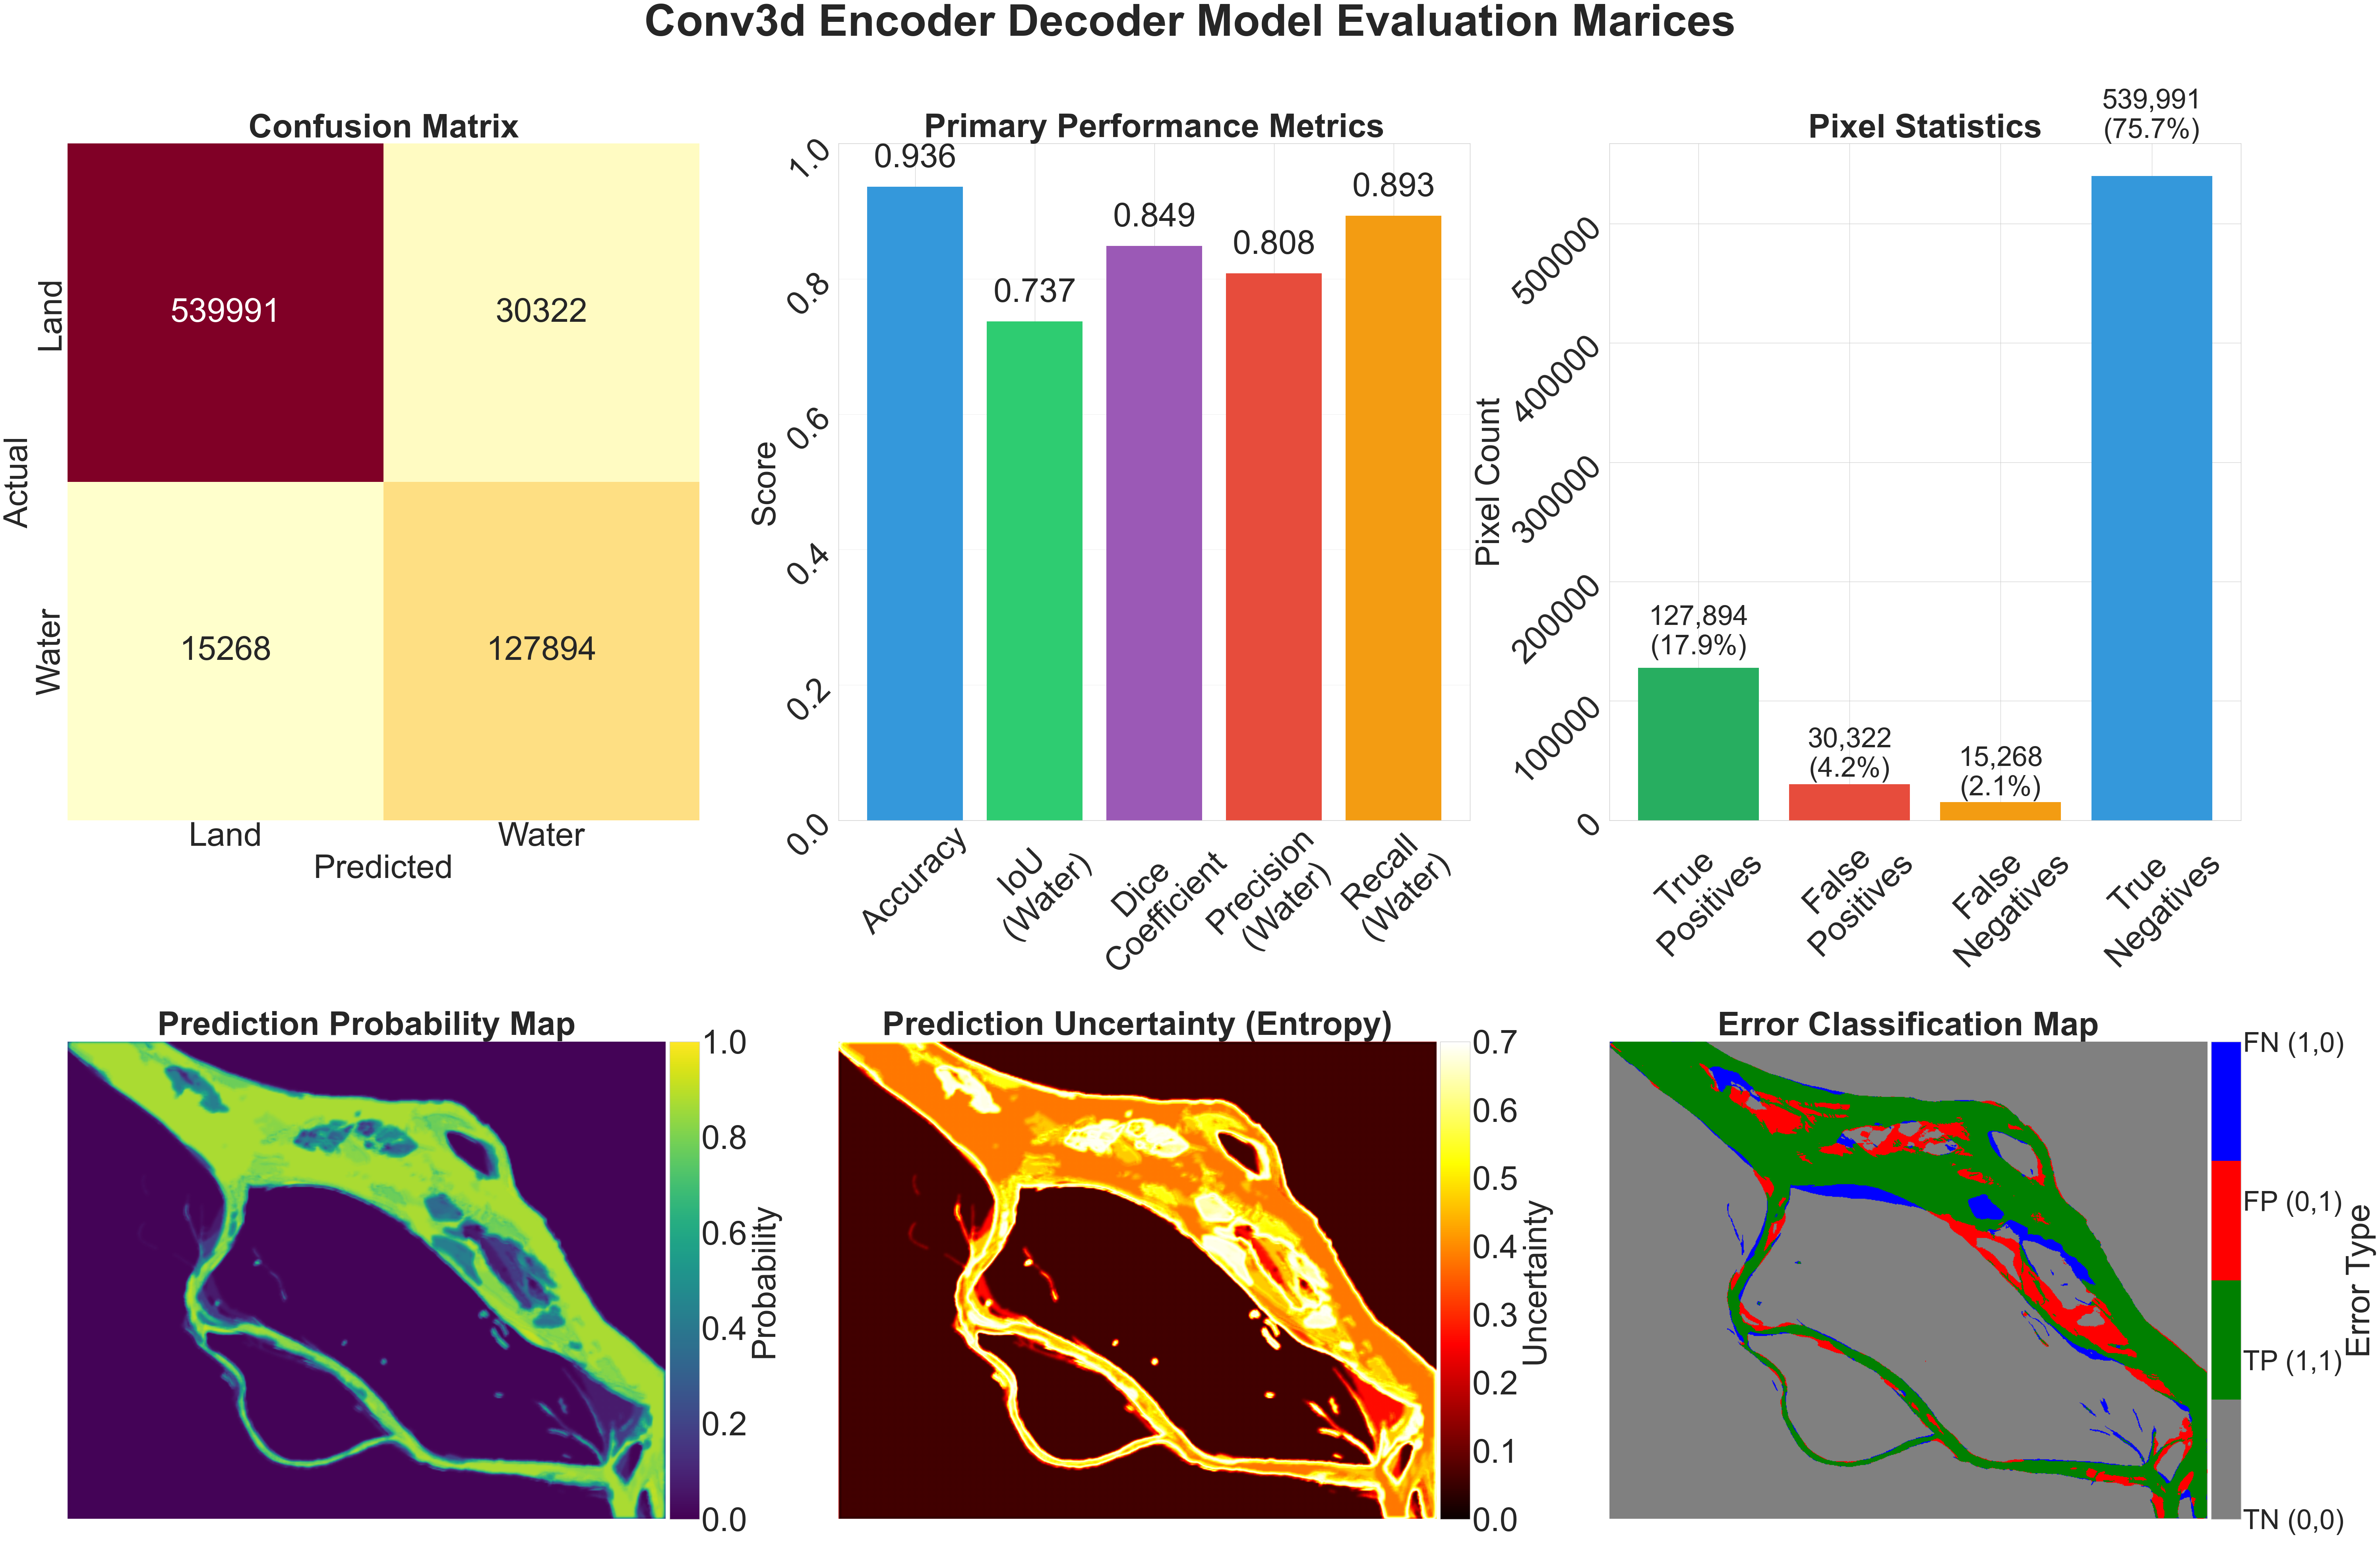

In [25]:
def Matricesplot(y_test, y_pred, model=None, x_test=None, device='cpu', sample_idx=0, save_path=None):
    """Enhanced visualization with metrics including probability and uncertainty maps"""
    # Ensure tensors
    if isinstance(y_test, np.ndarray):
        y_test = torch.from_numpy(y_test)
    if isinstance(y_pred, np.ndarray):
        y_pred = torch.from_numpy(y_pred)
    
    # Ensure binary
    y_test_bin = y_test.int()
    y_pred_bin = (y_pred > 0.5).int()
    
    # Calculate metrics
    metrics, cm = calculate_river_metrics(y_test_bin, y_pred_bin)
    
    # Get probability map if model and x_test are provided
    prob_map = None
    if model is not None and x_test is not None:
        with torch.no_grad():
            model.eval()
            if isinstance(x_test, np.ndarray):
                x_test = torch.from_numpy(x_test)
            x_test = x_test.to(device)
            predictions = model(x_test)
            
            if predictions.dim() > 2:
                prob_map = predictions[sample_idx, 0].cpu().numpy() if predictions.shape[1] == 1 else predictions[sample_idx].cpu().numpy()
            else:
                prob_map = predictions.cpu().numpy()
    
    # Create figure with 3x2 grid (6 plots total)
    fig = plt.figure(figsize=(60, 40))
    
    # 1. Confusion Matrix Heatmap
    ax1 = plt.subplot(2, 3, 1)
    heatmap = sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                          annot_kws={"size": 60},
                          xticklabels=['Land', 'Water'], 
                          yticklabels=['Land', 'Water'],
                          ax=ax1,
                          cbar=False)
    ax1.set_title('Confusion Matrix', fontsize=60, fontweight='bold')
    ax1.set_xlabel('Predicted', fontsize=60)
    ax1.set_ylabel('Actual', fontsize=60)
    ax1.tick_params(axis='both', labelsize=60)
    
    # 2. Primary Metrics
    ax2 = plt.subplot(2, 3, 2)
    primary_metrics = ['Accuracy', 'IoU\n(Water)', 'Dice\nCoefficient', 'Precision\n(Water)', 'Recall\n(Water)']
    primary_values = [
        metrics['accuracy'],
        metrics['iou_water'],
        metrics.get('dice_water', metrics.get('f1_water', 0)),
        metrics['precision_water'],
        metrics['recall_water']
    ]
    
    colors1 = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c', '#f39c12']
    bars1 = ax2.bar(primary_metrics, primary_values, color=colors1)
    ax2.set_ylim([0, 1])
    ax2.set_title('Primary Performance Metrics', fontsize=60, fontweight='bold')
    ax2.set_ylabel('Score', fontsize=60)
    ax2.tick_params(axis='both', labelsize=60, rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars1, primary_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=60)
    
    # 3. Pixel Statistics
    ax3 = plt.subplot(2, 3, 3)
    
    # Calculate pixel statistics
    total_pixels = cm.sum()
    tp, fp, fn, tn = cm[1, 1], cm[0, 1], cm[1, 0], cm[0, 0]
    
    stats_labels = ['True\nPositives', 'False\nPositives', 'False\nNegatives', 'True\nNegatives']
    stats_values = [tp, fp, fn, tn]
    stats_percentages = [tp/total_pixels*100, fp/total_pixels*100, 
                         fn/total_pixels*100, tn/total_pixels*100]
    
    colors3 = ['#27ae60', '#e74c3c', '#f39c12', '#3498db']
    bars3 = ax3.bar(stats_labels, stats_values, color=colors3)
    ax3.set_title('Pixel Statistics', fontsize=60, fontweight='bold')
    ax3.set_ylabel('Pixel Count', fontsize=60)
    ax3.tick_params(axis='both', labelsize=60, rotation=45)
    
    # Add both count and percentage
    for bar, val, pct in zip(bars3, stats_values, stats_percentages):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + height*0.05,
                f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=50)
    
    # 4. Probability Map (if available)
    ax4 = plt.subplot(2, 3, 4)
    if prob_map is not None:
        im1 = ax4.imshow(prob_map, cmap='viridis', vmin=0, vmax=1)
        ax4.set_title('Prediction Probability Map', fontsize=60, fontweight='bold')
        ax4.axis('off')
        divider1 = make_axes_locatable(ax4)
        cax1 = divider1.append_axes("right", size="5%", pad=0.1)
        cbar1 = plt.colorbar(im1, cax=cax1)
        cbar1.ax.tick_params(labelsize=60)
        cbar1.set_label('Probability', fontsize=60)
    else:
        # If no probability map, show actual mask
        if y_test.dim() > 2:
            actual_mask = y_test[sample_idx, 0].cpu().numpy() if y_test.shape[1] == 1 else y_test[sample_idx].cpu().numpy()
        else:
            actual_mask = y_test.cpu().numpy()
        
        im1 = ax4.imshow(actual_mask, cmap='Blues', vmin=0, vmax=1)
        ax4.set_title('Actual Water Mask', fontsize=60, fontweight='bold')
        ax4.axis('off')
        divider1 = make_axes_locatable(ax4)
        cax1 = divider1.append_axes("right", size="5%", pad=0.1)
        cbar1 = plt.colorbar(im1, cax=cax1, ticks=[0, 1])
        cbar1.ax.set_yticklabels(['Land', 'Water'], fontsize=60)
        cbar1.set_label('Class', fontsize=60)
    
    # 5. Uncertainty Map (if probability map is available)
    ax5 = plt.subplot(2, 3, 5)
    if prob_map is not None:
        # Calculate entropy as uncertainty measure
        prob_map_clipped = np.clip(prob_map, 1e-10, 1 - 1e-10)  # Avoid log(0)
        uncertainty = -prob_map_clipped * np.log(prob_map_clipped) - (1 - prob_map_clipped) * np.log(1 - prob_map_clipped)
        
        im2 = ax5.imshow(uncertainty, cmap='hot', vmin=0, vmax=0.7)
        ax5.set_title('Prediction Uncertainty (Entropy)', fontsize=60, fontweight='bold')
        ax5.axis('off')
        divider2 = make_axes_locatable(ax5)
        cax2 = divider2.append_axes("right", size="5%", pad=0.1)
        cbar2 = plt.colorbar(im2, cax=cax2)
        cbar2.ax.tick_params(labelsize=60)
        cbar2.set_label('Uncertainty', fontsize=60)
    else:
        # If no uncertainty map, show predicted mask
        if y_pred.dim() > 2:
            pred_mask = y_pred[sample_idx, 0].cpu().numpy() if y_pred.shape[1] == 1 else y_pred[sample_idx].cpu().numpy()
        else:
            pred_mask = y_pred.cpu().numpy()
        
        im2 = ax5.imshow(pred_mask, cmap='Blues', vmin=0, vmax=1)
        ax5.set_title('Predicted Water Mask', fontsize=60, fontweight='bold')
        ax5.axis('off')
        divider2 = make_axes_locatable(ax5)
        cax2 = divider2.append_axes("right", size="5%", pad=0.1)
        cbar2 = plt.colorbar(im2, cax=cax2, ticks=[0, 1])
        cbar2.ax.set_yticklabels(['Land', 'Water'], fontsize=60)
        cbar2.set_label('Class', fontsize=60)
    
    # 6. Error Classification Map
    ax6 = plt.subplot(2, 3, 6)
    
    # Get actual and predicted masks
    if y_test.dim() > 2:
        actual_mask = y_test[sample_idx, 0].cpu().numpy() if y_test.shape[1] == 1 else y_test[sample_idx].cpu().numpy()
    else:
        actual_mask = y_test.cpu().numpy()
    
    if y_pred.dim() > 2:
        pred_mask = y_pred[sample_idx, 0].cpu().numpy() if y_pred.shape[1] == 1 else y_pred[sample_idx].cpu().numpy()
    else:
        pred_mask = y_pred.cpu().numpy()
    
    # Create error map
    pred_mask_bin = (pred_mask > 0.5).astype(np.int32)
    error_map = np.zeros_like(actual_mask, dtype=np.int32)
    error_map[(actual_mask == 0) & (pred_mask_bin == 0)] = 0  # TN
    error_map[(actual_mask == 1) & (pred_mask_bin == 1)] = 1  # TP
    error_map[(actual_mask == 0) & (pred_mask_bin == 1)] = 2  # FP
    error_map[(actual_mask == 1) & (pred_mask_bin == 0)] = 3  # FN
    
    cmap_error = ListedColormap(['gray', 'green', 'red', 'blue'])
    im3 = ax6.imshow(error_map, cmap=cmap_error, vmin=0, vmax=3)
    ax6.set_title('Error Classification Map', fontsize=60, fontweight='bold')
    ax6.axis('off')
    divider3 = make_axes_locatable(ax6)
    cax3 = divider3.append_axes("right", size="5%", pad=0.1)
    cbar3 = plt.colorbar(im3, cax=cax3, ticks=[0, 1, 2, 3])
    cbar3.ax.set_yticklabels(['TN (0,0)', 'TP (1,1)', 'FP (0,1)', 'FN (1,0)'], fontsize=50)
    cbar3.set_label('Error Type', fontsize=60)
    
    plt.suptitle('Conv3d Encoder Decoder Model Evaluation Marices', fontsize=80, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # if save_path:
    #     plt.savefig(save_path, dpi=100, bbox_inches='tight')
    #     print(f"Metrics visualization saved to {save_path}")
    
    plt.show()
    
Matricesplot(y_test, y_pred, model=model, x_test=x_test, device=device)